# PaddleOCR 图像文字识别

使用 PaddleOCR 对 `paddle/` 目录下的图像进行 OCR 识别，提取文字内容并可视化展示结果。

In [22]:
# 安装依赖（如已安装可跳过）
#%pip install paddlepaddle paddleocr -q

## 1. 初始化 PaddleOCR

In [4]:
import mlp_chinese
mlp_chinese.setup_chinese()
from paddleocr import PaddleOCR
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np

[mpl_chinese] 使用字体: Noto Sans CJK JP


/root/paddle/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [ ]:


# Enable HEIC/HEIF decoding if pillow-heif is available.
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
except Exception:
    pass

ocr = PaddleOCR(use_textline_orientation=True, lang="ch")


def _load_font(size=18):
    font_candidates = [
        "C:/Windows/Fonts/simhei.ttf",
        "C:/Windows/Fonts/msyh.ttc",
        "C:/Windows/Fonts/simsun.ttc",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        "/System/Library/Fonts/PingFang.ttc",
    ]
    for font_path in font_candidates:
        if Path(font_path).exists():
            return ImageFont.truetype(font_path, size=size)
    return ImageFont.load_default()


def run_ocr(image_path):
    # PaddleOCR 3.x checks file suffix for string inputs; HEIC/HEIF must be decoded first.
    suffix = Path(image_path).suffix.lower()
    if suffix in {".heic", ".heif"}:
        pil_image = Image.open(image_path).convert("RGB")
        pred = ocr.predict(np.array(pil_image))[0]
    else:
        pred = ocr.predict(str(image_path))[0]

    boxes = pred.get("dt_polys") or []
    texts = pred.get("rec_texts") or []
    scores = pred.get("rec_scores") or []
    return boxes, texts, scores


def draw_ocr_result(image, boxes, texts, scores):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    font = _load_font(18)

    for box, text, score in zip(boxes, texts, scores):
        points = [tuple(map(float, point)) for point in box]
        draw.line(points + [points[0]], fill="red", width=3)

        label = f"{text} ({score:.2f})"
        x0, y0 = points[0]
        bbox = draw.textbbox((x0, y0), label, font=font)
        draw.rectangle(bbox, fill="red")
        draw.text((x0, y0), label, fill="white", font=font)

    return image

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


## 2. 扫描 `sample/` 目录下的图像文件

In [1]:
IMAGE_DIR = Path("../sample")
SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".webp", ".heic", ".heif"}

image_files = sorted(
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
)

print(f"在 {IMAGE_DIR}/ 目录下找到 {len(image_files)} 张图像：")
for f in image_files:
    print(f"  - {f.name}")

NameError: name 'Path' is not defined

## 3. 对每张图像执行 OCR 识别并展示结果


图像: IMG_7659(1).HEIC


Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.



识别到 28 个文本区域：

  [ 1] 东州道工程大区  (置信度: 0.2932)
  [ 2] 哈爾濱工程大学  (置信度: 0.7897)
  [ 3] 工程论理课堂作业  (置信度: 0.8744)
  [ 4] 于世  (置信度: 0.9933)
  [ 5] HARBIN ENGINEERING UNIVERSITY  (置信度: 0.9636)
  [ 6] S325517149:2026.3.30  (置信度: 0.9256)
  [ 7] 问题1、结合成海消失的案例谈谈如何运用好工程技术.实现人美与自然.  (置信度: 0.9038)
  [ 8] 的和谐发展.  (置信度: 0.9164)
  [ 9] 答：咸海消虫是典型的工程生街案例。由于过度引水发展灌忽视生态需水  (置信度: 0.8347)
  [10] 导致湖泊萎缩.生达浮统崩溃和区试环境恶化。  (置信度: 0.8055)
  [11] 要实沉人工自然的和谐发展，应从以下方面运用工程技术  (置信度: 0.8826)
  [12] 第一：坚持整体性再则.工程决策不能只追求局部经济效益，应得合考虑流域生态  (置信度: 0.7684)
  [13] 水循环手统及社会影响.避免破坏生态平衡。  (置信度: 0.8758)
  [14] 第二：遵循.自然、规律原则、水资源开发应控制在生态.承范国内保障基本生态.同水.  (置信度: 0.8237)
  [15] 防止对自然手统过度干预.  (置信度: 0.9066)
  [16] 第三：发展节约型与生态型工程技术。如推广节水灌溉、优化产业.结构.提高资源利同效章  (置信度: 0.8468)
  [17] 从源头减少对自然的压力.  (置信度: 0.9647)
  [18] 第四：落实不损害与补偿原则。对可能生的环境影响进行科学评估，尽量减少破坏，  (置信度: 0.8833)
  [19] 对不可避免的报害，应进行生态修复与合理补偿  (置信度: 0.9009)
  [20] 第五：坚持可持续发展与代除公平，工程活动不仅要足当代需求还应保障后代导有.  (置信度: 0.8240)
  [21] 良好生态环境的权利  (置信度: 0.9733)
  [22] 因此：工程技术应在论理约下服务于生态保护与社会，发展宗现人与自然的协洞统一。 

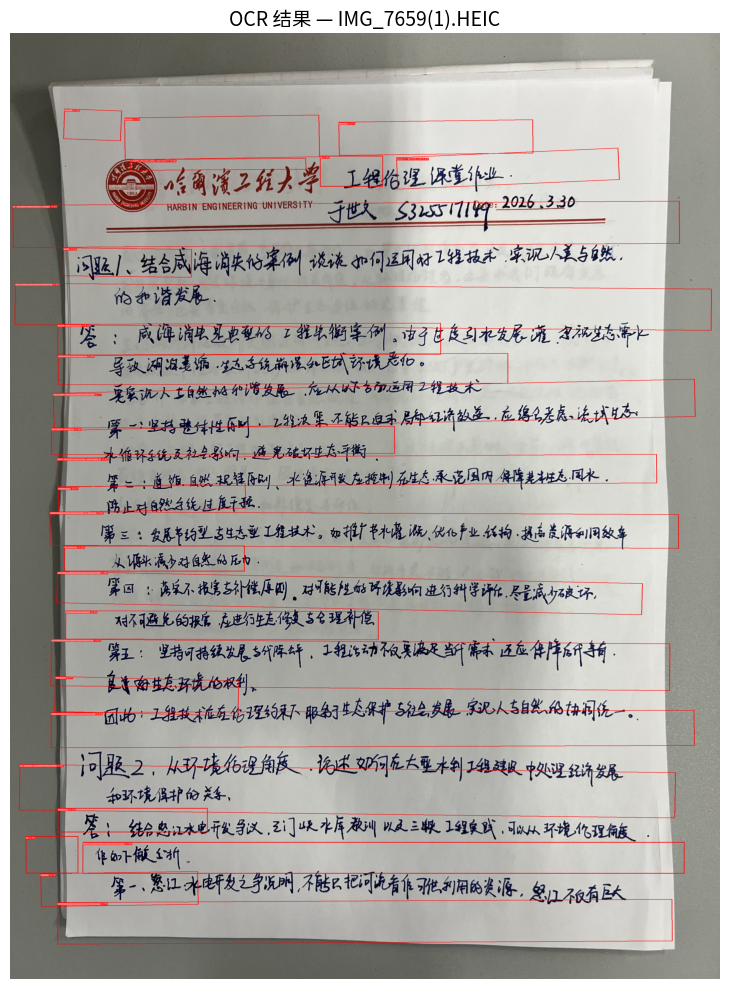


图像: IMG_7660(1).HEIC


Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.



识别到 0 个文本区域：



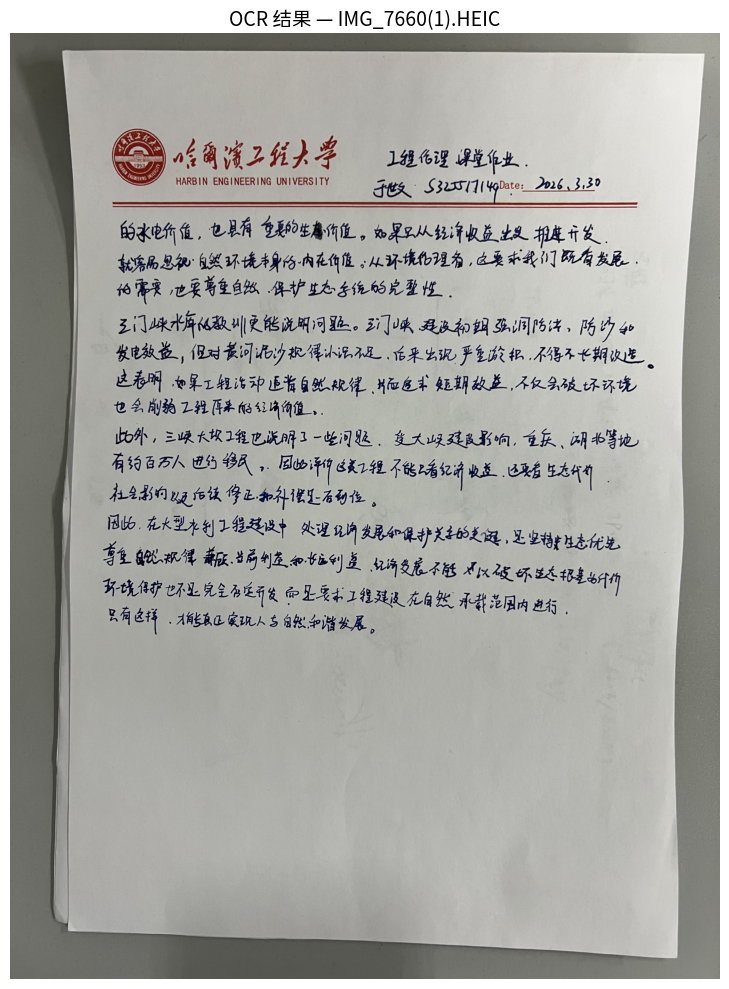


图像: general_ocr_002.png

识别到 33 个文本区域：

  [ 1] 登机牌  (置信度: 0.9980)
  [ 2] BOARDING  (置信度: 0.9774)
  [ 3] PASS  (置信度: 0.9863)
  [ 4] 航班FLIGHT  (置信度: 0.9971)
  [ 5] 日期DATE  (置信度: 0.9984)
  [ 6] 舱位  (置信度: 0.9990)
  [ 7] CLASS  (置信度: 0.9929)
  [ 8] 序号  (置信度: 0.9995)
  [ 9] SERIAL NO.  (置信度: 0.9571)
  [10] 座位号  (置信度: 0.9984)
  [11] SEAT NO.  (置信度: 0.9306)
  [12] MU2379 03DEC  (置信度: 0.9668)
  [13] w  (置信度: 0.5111)
  [14] 035  (置信度: 0.9982)
  [15] 目的地TO  (置信度: 0.9291)
  [16] 始发地  (置信度: 0.9988)
  [17] FROM  (置信度: 0.9888)
  [18] 登机口  (置信度: 0.9886)
  [19] GATE  (置信度: 0.9961)
  [20] 登机时间  (置信度: 0.9983)
  [21] BDT  (置信度: 0.9953)
  [22] 福州  (置信度: 0.9983)
  [23] FUZHOU  (置信度: 0.9858)
  [24] TAIYUAN  (置信度: 0.9918)
  [25] G11  (置信度: 0.9962)
  [26] 姓名NAME  (置信度: 0.9968)
  [27] 身份识别IDNO.  (置信度: 0.9636)
  [28] ZHANGQIWEI  (置信度: 0.9924)
  [29] 票号TKTNO.  (置信度: 0.9440)
  [30] 张祺伟  (置信度: 0.9954)
  [31] 票价FARE  (置信度: 0.9979)
  [32] ETKT7813699238489/1  (置信度: 0.9932)
  [33] 登机口于起飞前10分钟关闭GATES CLOSE 10 MINUTES 

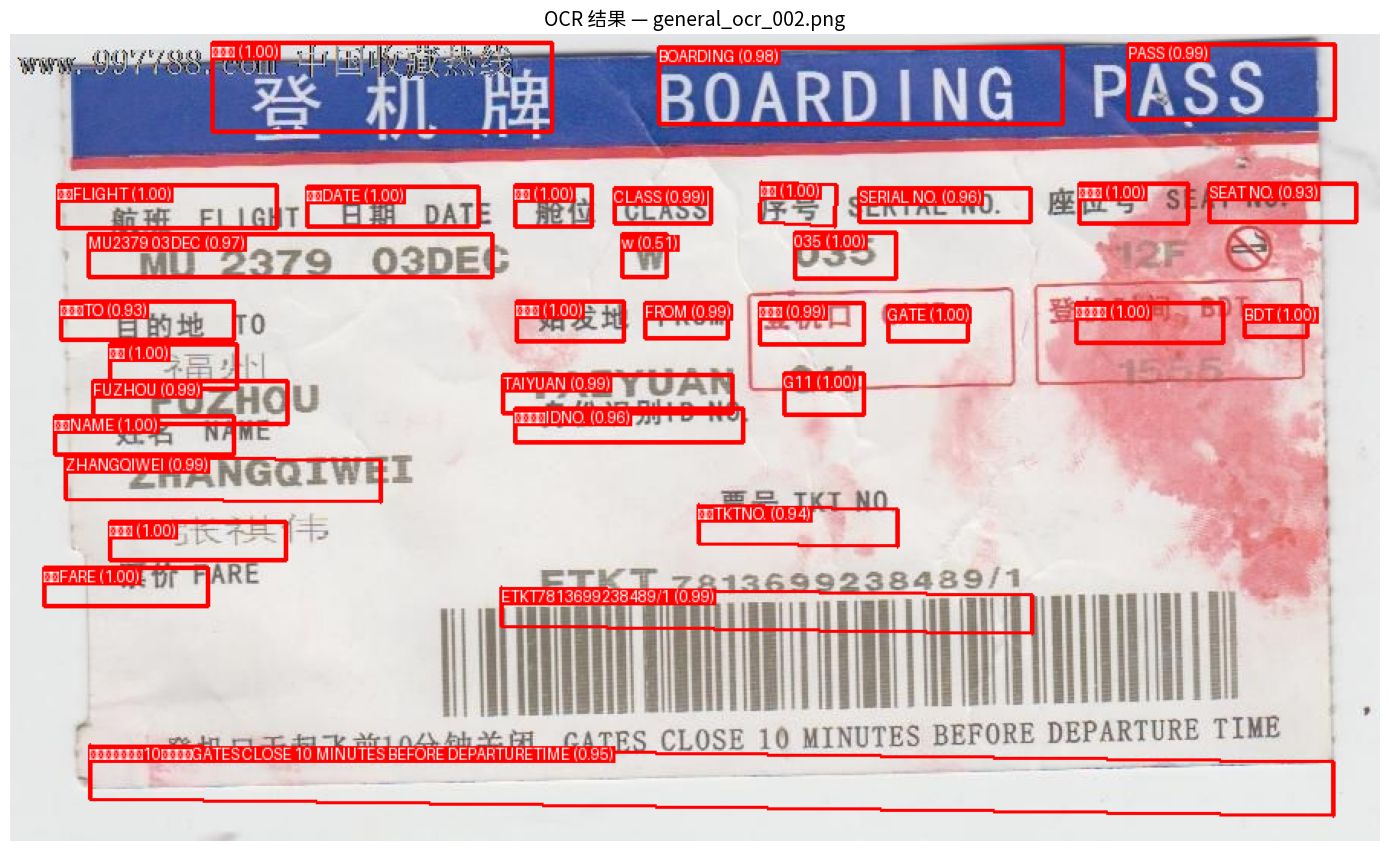

In [28]:
for img_path in image_files:
    print(f"\n{'='*60}")
    print(f"图像: {img_path.name}")
    print(f"{'='*60}")

    boxes, texts, scores = run_ocr(img_path)

    # 打印识别到的文字
    print(f"\n识别到 {len(texts)} 个文本区域：\n")
    for idx, (text, confidence) in enumerate(zip(texts, scores), 1):
        print(f"  [{idx:>2d}] {text}  (置信度: {confidence:.4f})")

    # 可视化：在原图上绘制检测框和文字
    image = Image.open(img_path).convert("RGB")
    vis_image = draw_ocr_result(image, boxes, texts, scores)

    plt.figure(figsize=(14, 10))
    plt.imshow(vis_image)
    plt.axis("off")
    plt.title(f"OCR 结果 — {img_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. 汇总所有识别结果到 DataFrame

In [27]:
import pandas as pd

rows = []
for img_path in image_files:
    boxes, texts, scores = run_ocr(img_path)
    for box, text, confidence in zip(boxes, texts, scores):
        rows.append({
            "文件": img_path.name,
            "识别文字": text,
            "置信度": round(float(confidence), 4),
            "左上角坐标": box[0],
            "右下角坐标": box[2],
        })

df = pd.DataFrame(rows)
df

Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (3024x4032) exceeds max_side_limit of 4000. Resizing to fit within limit.


,文件,识别文字,置信度,左上角坐标,右下角坐标
0,IMG_7659(1).HEIC,东州道工程大区,0.2932,"[232, 323]","[470, 459]"
1,IMG_7659(1).HEIC,哈爾濱工程大学,0.7897,"[488, 362]","[1318, 527]"
2,IMG_7659(1).HEIC,工程论理课堂作业,0.8744,"[1400, 380]","[2227, 511]"
3,IMG_7659(1).HEIC,于世,0.9933,"[1321, 524]","[1587, 653]"
4,IMG_7659(1).HEIC,HARBIN ENGINEERING UNIVERSITY,0.9636,"[513, 539]","[1260, 580]"
...,...,...,...,...,...
56,general_ocr_002.png,票号TKTNO.,0.9440,"[450, 308]","[580, 335]"
57,general_ocr_002.png,张祺伟,0.9954,"[65, 319]","[180, 344]"
58,general_ocr_002.png,票价FARE,0.9979,"[22, 349]","[129, 374]"
59,general_ocr_002.png,ETKT7813699238489/1,0.9932,"[321, 362]","[668, 392]"
